# 선형이어야 하는데, 선형이 맞나

가중치를 뽑는 노트북이자, 그 가중치를 믿어도 되는지 검사하는 노트북이다.

`logshare_shap_weights.ipynb`에서 y를 log(점유율)로 놓은 건 로짓 모형에서
`log(점유율) = x'β`가 나오기 때문이고, 이 형태라야 β를 효용 가중치라고 부를 수 있다.
그런데 이론이 선형을 요구한다고 데이터까지 선형이란 보장은 없다. 그걸 먼저 확인한다.

방법은 GBM 두 개를 끼워 넣는 거다.

- `depth 1`은 트리 깊이가 1이라 한 번에 변수 하나만 본다. 상호작용이 구조적으로 불가능하다.
- `depth 3`은 상호작용까지 잡는다.

Ridge, GBM(d1), GBM(d3) 셋을 같은 fold로 돌리면

```
d1 - ridge  =  변수 하나하나가 휘어서 생긴 차이
d3 - d1     =  변수 조합 때문에 생긴 차이
```

두 원인이 갈린다. 이걸 못 가르면 "Ridge가 진다"까지만 알고 왜 지는지는 모른다.

결론부터: 곡률이 있어서 `cost`와 `data`를 변환했고, 통화·문자가 98% 겹쳐 있어서
문자를 회귀에서 뺐다. 아래가 그 과정이다.


In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)

DATA = Path("../data")
plans = pd.read_csv(DATA / "통신요금제_통합데이터_최종.csv", dtype={"plan_id": str})
benefits = pd.read_csv(DATA / "통신요금제_혜택상세_최종.csv", dtype={"plan_id": str})
prices = pd.read_csv(DATA / "ott_prices.csv")
price_map = dict(zip(prices.service, prices.monthly_won.astype(int)))

print(f"plans {len(plans):,}행 · benefits {len(benefits):,}행")

plans 2,759행 · benefits 5,581행


In [2]:
# 모집단·피처 구성은 logshare_shap_weights.ipynb 와 동일해야 비교가 의미 있다
mvno_all = plans[plans.carrier_type == "MVNO"].copy()
MNO_BRANDS = ["SKT", "KT", "LG U+", "LGU+"]
mvno = mvno_all[~mvno_all.mvno_brand.isin(MNO_BRANDS)].copy()


def qos_mbps(value):
    if pd.isna(value):
        return 0.0
    m = re.match(r"([\d.]+)\s*(kbps|mbps)", str(value).strip().lower().replace(" ", ""))
    if not m:
        return 0.0
    n = float(m.group(1))
    return n / 1000 if m.group(2) == "kbps" else n


def build(df):
    d = df.copy()
    d["cost_month"] = d.discounted_fee

    extra = benefits[benefits.benefit_category == "추가데이터"].copy()
    extra["gb"] = extra.benefit_name.fillna("").str.extract(r"([\d.]+)\s*GB", flags=re.I)[0].astype(float)
    d["extra_gb"] = d.plan_id.map(extra.groupby("plan_id").gb.sum()).fillna(0)
    d["data_total_gb"] = np.where(
        d.data_unlimited, 300,
        (d.data_gb.fillna(d.daily_data_gb.fillna(0) * 30) + d.extra_gb).clip(0, 300)
    )
    d["qos"] = d.data_throttle_speed.map(qos_mbps)
    d["tether_gb"] = d.tethering_gb.fillna(0)
    # 무제한은 유한수로 적을 수밖에 없다. 이 상수가 결과를 좌우하는지는 뒤에서 따로 검사한다.
    d["voice_min"] = np.where(d.voice_unlimited, 1000, d.voice_minutes.fillna(0)).clip(0, 1000)
    d["sms_cnt"] = np.where(d.sms_unlimited, 1000, d.sms_count.fillna(0)).clip(0, 1000)

    ott_b = benefits[benefits.benefit_category == "OTT/구독"]
    ott_services = d.plan_id.map(
        ott_b.groupby("plan_id")["benefit_service"].apply(lambda v: sorted(set(v.dropna())))
    )
    d["ott_value"] = ott_services.apply(
        lambda s: sum(price_map.get(x, 0) for x in s) if isinstance(s, list) else 0
    )
    return d


mvno = build(mvno)
AXES = ["cost_month", "data_total_gb", "qos", "tether_gb", "voice_min", "sms_cnt", "ott_value"]

mvno["market_share"] = mvno.subscriber_count / mvno.subscriber_count.sum()
y = np.log(mvno["market_share"].clip(lower=1e-12).values)

brand_dummies = pd.get_dummies(mvno.mvno_brand, prefix="brand", dummy_na=True).astype(float)
X = pd.concat([mvno[AXES].reset_index(drop=True),
               brand_dummies.reset_index(drop=True)], axis=1)

print(f"표본 {len(X):,} · 피처 {X.shape[1]}개 "
      f"(축 {len(AXES)} + 브랜드 더미 {brand_dummies.shape[1]})")

표본 2,158 · 피처 35개 (축 7 + 브랜드 더미 28)


## 세 모델을 같은 fold에

fold를 공유해야 짝지어 뺄 수 있고, 그래야 fold마다 다른 난이도가 상쇄된다.

트리 쪽 트리 개수는 fold 안에서 early stopping으로 정한다. 처음엔 둘 다 `n_estimators`를
같게 줬는데, depth 1은 stump라 같은 성능을 내려면 트리가 훨씬 많이 필요하다. 고정해두면
depth 1만 과소적합되고 그 차이가 통째로 "상호작용"으로 잡힌다. 그래서 각자 알아서
멈추게 했다.

Ridge는 표준화하고 fold 안에서 `RidgeCV`로 alpha를 고른다.


In [3]:
import lightgbm as lgb
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score
from sklearn.model_selection import RepeatedKFold, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

CV = RepeatedKFold(n_splits=5, n_repeats=5, random_state=0)
MODELS = ["ridge", "gbm_d1", "gbm_d3"]
ALPHAS = np.logspace(-3, 3, 25)


def ridge():
    return make_pipeline(StandardScaler(), RidgeCV(alphas=ALPHAS))


def lgb_model(depth, seed=0):
    return lgb.LGBMRegressor(
        n_estimators=3000, learning_rate=0.05,
        max_depth=depth, num_leaves=2 ** depth,   # depth1 -> 잎 2개 = stump = 가법
        min_child_samples=20, reg_lambda=1.0,
        random_state=seed, verbosity=-1,
    )


def run_cv(X, y, cv=CV):
    """fold별 out-of-sample R2를 모델별로 모은다. fold는 세 모델이 공유."""
    out = {k: [] for k in MODELS}
    for tr, te in cv.split(X):
        Xtr, Xte, ytr, yte = X.iloc[tr], X.iloc[te], y[tr], y[te]

        m = ridge().fit(Xtr, ytr)
        out["ridge"].append(r2_score(yte, m.predict(Xte)))

        itr, iva = train_test_split(np.arange(len(tr)), test_size=0.2, random_state=0)
        for depth, key in ((1, "gbm_d1"), (3, "gbm_d3")):
            g = lgb_model(depth)
            g.fit(Xtr.iloc[itr], ytr[itr],
                  eval_set=[(Xtr.iloc[iva], ytr[iva])],
                  callbacks=[lgb.early_stopping(50, verbose=False)])
            out[key].append(r2_score(yte, g.predict(Xte)))
    return {k: np.array(v) for k, v in out.items()}


def ridge_cv(Xs, y, cv=CV):
    """Ridge만. 변환 탐색처럼 트리가 필요 없는 비교에 쓴다."""
    return np.array([r2_score(y[te], ridge().fit(Xs.iloc[tr], y[tr]).predict(Xs.iloc[te]))
                     for tr, te in cv.split(Xs)])


def gap(scores, a, b):
    """fold를 짝지어 뺀 차이의 평균과 95% 폭. 짝지어야 fold 난이도 차이가 상쇄된다."""
    d = scores[a] - scores[b]
    return d.mean(), 1.96 * d.std(ddof=1) / np.sqrt(len(d))


def diff(new, cur):
    d = new - cur
    return d.mean(), 1.96 * d.std(ddof=1) / np.sqrt(len(d))


def coef_of(Xs, cols, yv=None):
    """부트스트랩에서 X 만 리샘플링하고 y 를 안 넘기면 짝이 어긋난다. yv 를 꼭 같이 넘길 것."""
    p = ridge().fit(Xs, y if yv is None else yv)
    return pd.Series(p[-1].coef_, index=Xs.columns)[cols]


scores = run_cv(X, y)
print(pd.DataFrame(scores).agg(["mean", "std"]).round(4).to_string())

       ridge  gbm_d1  gbm_d3
mean  0.3763  0.5257  0.5870
std   0.0405  0.0311  0.0293


In [4]:
nonlin = gap(scores, "gbm_d1", "ridge")
inter = gap(scores, "gbm_d3", "gbm_d1")

report = pd.DataFrame(
    [["비선형성(곡률)", "gbm_d1 - ridge", *nonlin],
     ["상호작용", "gbm_d3 - gbm_d1", *inter]],
    columns=["항목", "비교", "ΔR²", "±95%"],
)
# 단측 판정. 갭이 유의하게 음수면 "복잡한 모델이 더 나쁨" = 증거 없음이지 유의가 아니다
report["유의"] = np.where(report["ΔR²"] - report["±95%"] > 0, "예", "아니오")
print(report.round(4).to_string(index=False))

sig_nonlin = nonlin[0] - nonlin[1] > 0
sig_inter = inter[0] - inter[1] > 0
verdict = {
    (False, False): "Ridge 그대로. 선형 명세로 진행.",
    (False, True): "곱항 후보를 SHAP으로 뽑아 Ridge에 추가.",
    (True, False): "곡률 있음. 원자료 그대로의 선형식은 오설정이라 변수 변환 먼저.",
    (True, True): "변환 먼저, 그 뒤 상호작용 재검정.",
}[(sig_nonlin, sig_inter)]
print(f"\n판정: {verdict}")

      항목              비교    ΔR²   ±95% 유의
비선형성(곡률)  gbm_d1 - ridge 0.1494 0.0083  예
    상호작용 gbm_d3 - gbm_d1 0.0613 0.0055  예

판정: 변환 먼저, 그 뒤 상호작용 재검정.


## 결과 읽는 법

| 곡률 갭 | 상호작용 갭 | 할 일 |
|---|---|---|
| ~0 | ~0 | Ridge 그대로 |
| ~0 | 유의 | SHAP으로 페어 뽑아 곱항 추가 |
| 유의 | ~0 | 변수 변환 먼저. 원자료 선형식은 틀린 거다 |
| 유의 | 유의 | 변환하고 나서 상호작용 다시 봄 |

상호작용이 없어도 곡률이 있으면 원자료 선형식은 오설정이다. 변환하고 나면 여전히
선형이라 계수를 가중치로 읽는 건 그대로 되고, 단위만 바뀐다.

둘 다 나오면 변환이 먼저다. 곡률을 남긴 채 상호작용부터 보면, 변환으로 없앨 수 있었던
몫까지 곱항이 가져간다.


## 어떤 변환을 쓸까

후보를 `raw` / `log1p` / `sqrt` 셋으로 제한했다. 스플라인이 더 잘 맞겠지만 축 하나가
계수 여러 개로 쪼개져서 "이 축의 가중치"를 만들 수가 없다. 축당 계수 하나가 이 작업의
제약이라 여기선 못 쓴다.

7축 × 3후보 = 2,187가지 전수는 과해서 greedy로 갔다. 한 축씩 바꿔보고 좋아지면 채택,
더 안 바뀔 때까지 반복.

채택 기준을 처음엔 "평균 R²가 1e-4라도 오르면"으로 잡았는데 너무 헐거웠다. 기여가
+0.0005밖에 안 되는 변환까지 주워와서 축 3개가 잡음으로 들어왔다. fold를 짝지은
95% 구간이 0을 넘으면서 동시에 평균 개선이 0.005 이상일 때만 채택하도록 고쳤다.


In [5]:
TRANSFORMS = {"raw": lambda v: v, "log1p": np.log1p, "sqrt": np.sqrt}
MIN_GAIN = 0.005          # 이보다 작으면 실질적으로 의미 없다


def apply_spec(X, spec):
    out = X.copy()
    for ax, t in spec.items():
        out[ax] = TRANSFORMS[t](X[ax].values)
    return out


def accepts(new, cur):
    m, half = diff(new, cur)
    return m - half > 0 and m >= MIN_GAIN


spec = {ax: "raw" for ax in AXES}
cur = ridge_cv(X, y)
print(f"raw ridge R² = {cur.mean():.4f}")

for _ in range(3):
    changed = False
    for ax in AXES:
        for t in TRANSFORMS:
            if t == spec[ax]:
                continue
            trial = dict(spec, **{ax: t})
            new = ridge_cv(apply_spec(X, trial), y)
            if accepts(new, cur):
                print(f"  {ax}: -> {t}   R² {new.mean():.4f}  (+{(new - cur).mean():.4f})")
                cur, spec, changed = new, trial, True
    if not changed:
        break

Xt = apply_spec(X, spec)
print(f"\nspec = {spec}")
print(f"변환 후 ridge R² = {cur.mean():.4f}")

print("\n변환별 기여 (해당 축만 raw 로 되돌렸을 때의 손실):")
for ax, t in spec.items():
    if t == "raw":
        continue
    m, half = diff(cur, ridge_cv(apply_spec(X, dict(spec, **{ax: "raw"})), y))
    print(f"  {ax:<14} {t:<6} +{m:.4f} (±{half:.4f})")

raw ridge R² = 0.3763


  cost_month: -> sqrt   R² 0.4309  (+0.0546)


  data_total_gb: -> log1p   R² 0.4825  (+0.0517)



spec = {'cost_month': 'sqrt', 'data_total_gb': 'log1p', 'qos': 'raw', 'tether_gb': 'raw', 'voice_min': 'raw', 'sms_cnt': 'raw', 'ott_value': 'raw'}
변환 후 ridge R² = 0.4825

변환별 기여 (해당 축만 raw 로 되돌렸을 때의 손실):


  cost_month     sqrt   +0.0648 (±0.0039)


  data_total_gb  log1p  +0.0517 (±0.0050)


In [6]:
scores_t = run_cv(Xt, y)
print(pd.DataFrame(scores_t).agg(["mean", "std"]).round(4).to_string())

for label, a, b in [("곡률", "gbm_d1", "ridge"), ("상호작용", "gbm_d3", "gbm_d1")]:
    before, after = gap(scores, a, b), gap(scores_t, a, b)
    print(f"{label:<6} {before[0]:+.4f} (±{before[1]:.4f})  ->  {after[0]:+.4f} (±{after[1]:.4f})")

closed = (scores_t["ridge"].mean() - scores["ridge"].mean()) / \
         (scores["gbm_d3"].mean() - scores["ridge"].mean())
print(f"\nGBM 대비 격차 중 변환이 회수한 비율: {closed:.0%}")

sig_inter_t = gap(scores_t, "gbm_d3", "gbm_d1")[0] - gap(scores_t, "gbm_d3", "gbm_d1")[1] > 0

       ridge  gbm_d1  gbm_d3
mean  0.4825  0.5258  0.5872
std   0.0357  0.0310  0.0293
곡률     +0.1494 (±0.0083)  ->  +0.0433 (±0.0057)
상호작용   +0.0613 (±0.0055)  ->  +0.0614 (±0.0054)

GBM 대비 격차 중 변환이 회수한 비율: 50%


### 잔차가 평평해졌나

처음엔 축별 산점도(x vs log_share)를 위아래로 놓고 "변환하면 선이 펴지겠지" 했는데
그림이 거의 안 변했다. 당연한 거였다. 구간을 순위로 나누니 위아래 행의 구간 평균 y가
정의상 같고, x 간격만 바뀐다. 그 그림으로는 변환 효과를 볼 수가 없다.

그래서 잔차로 바꿨다. 선형 모델을 적합시키고 남은 잔차를 축별 구간 평균으로 찍는다.
선형 명세가 맞으면 잔차에 그 축의 패턴이 안 남아 있어야 하니 0 선에 붙어 평평해야 한다.
휘어 있으면 그 축을 아직 못 펴고 있다는 뜻이다.

구간은 두 경우 모두 원자료 순위로 나눈다. 그래야 같은 요금제 묶음끼리 비교가 된다.


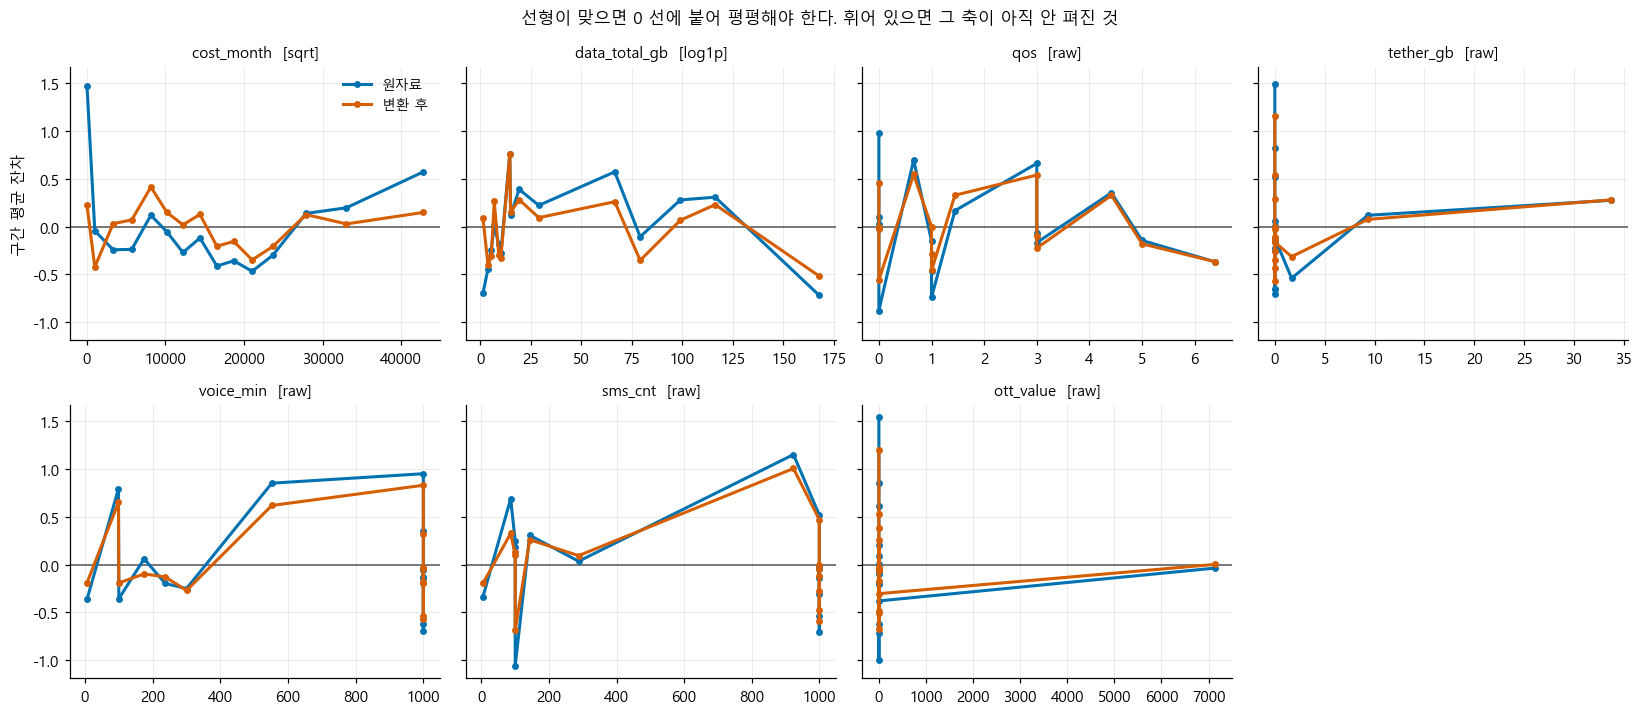

               원자료 폭   변환 폭
cost_month     1.937  0.835
data_total_gb  1.482  1.273
qos            1.857  1.100
tether_gb      2.192  1.726
voice_min      1.646  1.396
sms_cnt        2.209  1.690
ott_value      2.538  1.868


In [7]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams["font.family"] = "Malgun Gothic"   # 한글 라벨. 없으면 "NanumGothic"
rcParams["axes.unicode_minus"] = False      # 마이너스 기호 깨짐 방지
rcParams["figure.dpi"] = 110

# Okabe-Ito 계열. 색각이상에서도 구분되는 조합이다
BLUE, GREEN, VERM, MUTED = "#0072B2", "#009E73", "#D55E00", "#8a8a85"


def tidy(ax):
    ax.grid(alpha=0.25, lw=0.6)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)


def ci95(v):
    return 1.96 * np.std(v, ddof=1) / np.sqrt(len(v))


def fit_resid(Xs):
    return y - ridge().fit(Xs, y).predict(Xs)


def binned_resid(ax_name, r, q=15):
    """구간은 항상 원자료 순위로 나눈다. 그래야 두 모델의 같은 구간을 비교할 수 있다."""
    b = pd.qcut(pd.Series(X[ax_name].values).rank(method="first"), q=q, duplicates="drop")
    g = pd.DataFrame({"x": X[ax_name].values, "r": r, "b": b}).groupby("b", observed=True).mean()
    return g.x.values, g.r.values


r_raw, r_t = fit_resid(X), fit_resid(Xt)

fig, grid = plt.subplots(2, 4, figsize=(15, 6.6), sharey=True)
grid = grid.flatten()
for i, name in enumerate(AXES):
    ax = grid[i]
    ax.axhline(0, color="#555", lw=1)
    for r, color, label in ((r_raw, BLUE, "원자료"), (r_t, VERM, "변환 후")):
        bx, br = binned_resid(name, r)
        ax.plot(bx, br, color=color, lw=2, marker="o", ms=3.5, label=label)
    tidy(ax)
    ax.set_title(f"{name}  [{spec[name]}]", fontsize=10)
    if i == 0:
        ax.set_ylabel("구간 평균 잔차")
        ax.legend(frameon=False, fontsize=9)
for j in range(len(AXES), len(grid)):
    fig.delaxes(grid[j])

fig.suptitle("선형이 맞으면 0 선에 붙어 평평해야 한다. 휘어 있으면 그 축이 아직 안 펴진 것",
             fontsize=11)
fig.tight_layout()
fig.savefig("fig_transform_axes.png", bbox_inches="tight")
plt.show()

print(pd.DataFrame({
    "원자료 폭": [np.ptp(binned_resid(a, r_raw)[1]) for a in AXES],
    "변환 폭": [np.ptp(binned_resid(a, r_t)[1]) for a in AXES],
}, index=AXES).round(3).to_string())

## 상호작용, 어느 페어인가

변환하고도 갭이 남아서 들여다본다. SHAP 상호작용 값으로 페어 순위를 매기는데 이건
답이 아니라 후보 목록이다. 뽑은 페어를 곱항으로 Ridge에 넣어서 갭이 실제로 메워지는지
봐야 끝난다. R²가 거의 안 움직이면 트리가 잡는 게 곱셈형이 아니라는 뜻이고, 그럼
곱항을 넣을 이유가 없다.


In [8]:
if sig_inter_t:
    import shap

    full = lgb_model(3).fit(Xt, y)
    iv = shap.TreeExplainer(full).shap_interaction_values(Xt)
    off = np.abs(iv).mean(0)
    np.fill_diagonal(off, 0)

    cols = list(Xt.columns)
    pairs = sorted(
        ((off[i, j], cols[i], cols[j])
         for i in range(len(cols)) for j in range(i + 1, len(cols))
         if cols[i] in AXES and cols[j] in AXES),   # 브랜드 더미 페어는 가중치와 무관
        reverse=True,
    )[:3]
    for v, a, b in pairs:
        print(f"{a} x {b}: {v:.4f}")

    X2 = Xt.assign(**{f"{a}_x_{b}": Xt[a] * Xt[b] for _, a, b in pairs})
    s2 = run_cv(X2, y)
    print(f"\n곱항 추가 후 ridge R²: {s2['ridge'].mean():.4f}"
          f" (추가 전 {scores_t['ridge'].mean():.4f}, gbm_d3 {scores_t['gbm_d3'].mean():.4f})")
    print("거의 안 메워지면 트리가 잡는 건 곱셈형이 아니다. 곱항을 넣지 말 것.")
else:
    print("상호작용 갭 유의하지 않음. 건너뜀.")

cost_month x data_total_gb: 0.1834
cost_month x qos: 0.0808
data_total_gb x qos: 0.0667



곱항 추가 후 ridge R²: 0.4891 (추가 전 0.4825, gbm_d3 0.5872)
거의 안 메워지면 트리가 잡는 건 곱셈형이 아니다. 곱항을 넣지 말 것.


### 예측력과 갭 분해

왼쪽. GBM이 Ridge보다 높다. 이건 그냥 사실이다. 다만 GBM에는 꺼낼 계수가 없어서
가중치를 못 만든다.

오른쪽. 변환이 곡률 갭만 줄이고 상호작용 갭은 건드리지 않는다. 두 갭이 서로 다른 걸
재고 있다는 확인이기도 하다.


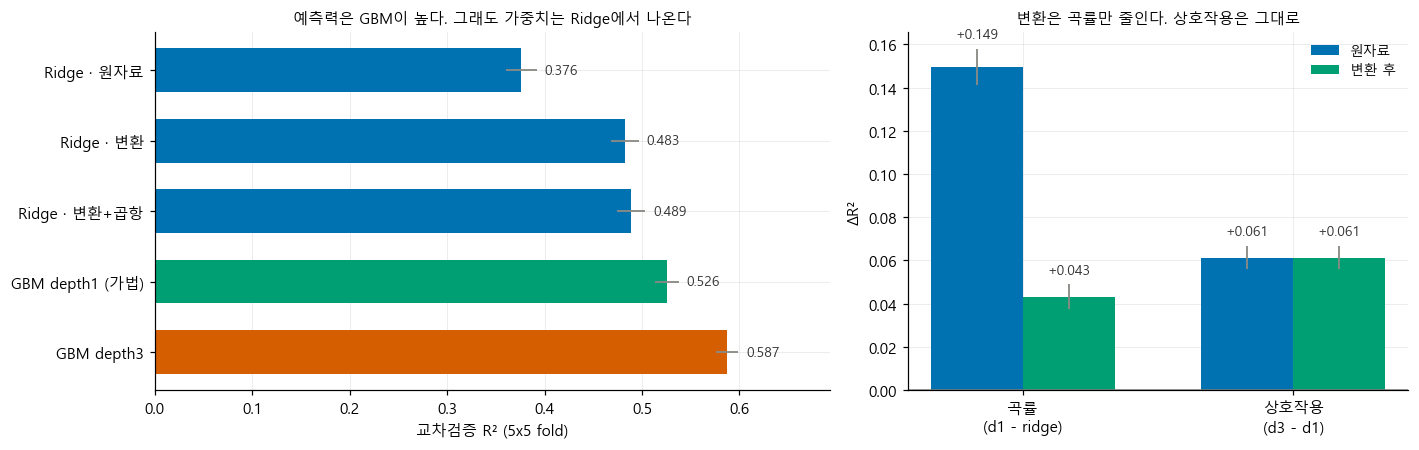

In [9]:
try:
    ridge_int = s2["ridge"]
except NameError:
    ridge_int = None

rows = [("Ridge · 원자료", scores["ridge"], BLUE),
        ("Ridge · 변환", scores_t["ridge"], BLUE)]
if ridge_int is not None:
    rows.append(("Ridge · 변환+곱항", ridge_int, BLUE))
rows += [("GBM depth1 (가법)", scores_t["gbm_d1"], GREEN),
         ("GBM depth3", scores_t["gbm_d3"], VERM)]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.35, 1]})

pos = np.arange(len(rows))
a1.barh(pos, [r[1].mean() for r in rows], xerr=[ci95(r[1]) for r in rows],
        color=[r[2] for r in rows], height=0.62, error_kw=dict(ecolor=MUTED, lw=1.2))
a1.set_yticks(pos, [r[0] for r in rows], fontsize=10)
a1.invert_yaxis()
for p, r in zip(pos, rows):
    a1.text(r[1].mean() + ci95(r[1]) + 0.008, p, f"{r[1].mean():.3f}",
            va="center", fontsize=9, color="#333")
a1.set_xlabel("교차검증 R² (5x5 fold)")
a1.set_xlim(0, max(r[1].mean() for r in rows) * 1.18)
a1.set_title("예측력은 GBM이 높다. 그래도 가중치는 Ridge에서 나온다", fontsize=10)
tidy(a1)

labels = ["곡률\n(d1 - ridge)", "상호작용\n(d3 - d1)"]
before = [gap(scores, "gbm_d1", "ridge"), gap(scores, "gbm_d3", "gbm_d1")]
after = [gap(scores_t, "gbm_d1", "ridge"), gap(scores_t, "gbm_d3", "gbm_d1")]
w, g = 0.34, np.arange(2)
a2.bar(g - w / 2, [b[0] for b in before], w, yerr=[b[1] for b in before],
       color=BLUE, label="원자료", error_kw=dict(ecolor=MUTED, lw=1.2))
a2.bar(g + w / 2, [a[0] for a in after], w, yerr=[a[1] for a in after],
       color=GREEN, label="변환 후", error_kw=dict(ecolor=MUTED, lw=1.2))
for xx, (v, e) in zip(g - w / 2, before):
    a2.text(xx, v + e + 0.005, f"{v:+.3f}", ha="center", fontsize=9, color="#333")
for xx, (v, e) in zip(g + w / 2, after):
    a2.text(xx, v + e + 0.005, f"{v:+.3f}", ha="center", fontsize=9, color="#333")
a2.axhline(0, color=MUTED, lw=1)
a2.set_xticks(g, labels, fontsize=10)
a2.set_ylabel("ΔR²")
a2.set_title("변환은 곡률만 줄인다. 상호작용은 그대로", fontsize=10)
a2.legend(frameon=False, fontsize=9)
tidy(a2)

fig.tight_layout()
fig.savefig("fig_model_gaps.png", bbox_inches="tight")
plt.show()

## 문자 계수가 음수로 나온다

여기서 한 번 막혔다. 변환까지 끝내고 계수를 봤더니 `sms_cnt`가 음수다. 문자를 많이
주는 요금제일수록 가입자가 적다는 뜻인데, 혜택인데 효용이 마이너스면 말이 안 된다.

처음엔 누락변수 탓이라고 봤다. 문자를 많이 주는 게 저가 요금제의 특징이라 요금제 등급의
대리 노릇을 하는 거라고. `scoring.py`도 같은 이유로 문자를 빼놓고 있었다(주석에 계수
-0.902라고 적혀 있다).

그런데 통화와 문자가 같이 움직이는 게 눈에 걸려서 겹침을 먼저 봤다.


In [10]:
v = mvno.voice_unlimited.values.astype(int)
s = mvno.sms_unlimited.values.astype(int)

print("교차표 (행=통화무제한, 열=문자무제한)")
print(pd.crosstab(pd.Series(v, name="voice"), pd.Series(s, name="sms")).to_string())
print(f"\n플래그 상관 {np.corrcoef(v, s)[0, 1]:.3f} · 일치율 {(v == s).mean():.1%}")
print(f"연속 인코딩 상관 voice_min vs sms_cnt {np.corrcoef(X.voice_min, X.sms_cnt)[0, 1]:.3f}")

both = coef_of(Xt, ["voice_min", "sms_cnt"])
only_s = coef_of(Xt.drop(columns=["voice_min"]), ["sms_cnt"])
only_v = coef_of(Xt.drop(columns=["sms_cnt"]), ["voice_min"])
print(f"\n둘 다 넣음    voice {both.voice_min:+.3f}   sms {both.sms_cnt:+.3f}")
print(f"통화 빼면                    sms {only_s.sms_cnt:+.3f}")
print(f"문자 빼면     voice {only_v.voice_min:+.3f}")

rng = np.random.default_rng(0)
rows = []
for _ in range(300):
    i = rng.choice(len(Xt), len(Xt), replace=True)
    rows.append(coef_of(Xt.iloc[i], ["voice_min", "sms_cnt"], y[i]))
boot = pd.DataFrame(rows)
print(f"\n부트스트랩 300회 두 계수의 상관 {boot.corr().iloc[0, 1]:.3f}"
      "   (-1 에 가까우면 서로 상쇄 중)")
print(boot.describe().loc[["mean", "std", "min", "max"]].round(3).to_string())

교차표 (행=통화무제한, 열=문자무제한)
sms      0     1
voice           
0      998     2
1       38  1120

플래그 상관 0.963 · 일치율 98.1%
연속 인코딩 상관 voice_min vs sms_cnt 0.943

둘 다 넣음    voice +0.461   sms -0.230
통화 빼면                    sms +0.199
문자 빼면     voice +0.260



부트스트랩 300회 두 계수의 상관 -0.895   (-1 에 가까우면 서로 상쇄 중)
      voice_min  sms_cnt
mean      0.461   -0.233
std       0.092    0.094
min       0.216   -0.565
max       0.800    0.020


## 음수의 정체는 공선성이었다

2,158개 중 40개만 다르다. 통화 무제한을 주는 요금제는 문자 무제한도 같이 준다. 묶음
상품이라 따로 떼어낼 수가 없다.

거의 같은 변수 둘을 같이 넣으면 회귀는 한쪽을 크게 +, 다른 쪽을 크게 -로 갈라놓고
서로 상쇄시킨다. 부트스트랩에서 두 계수의 상관이 -0.9 근처로 나오는 게 그 증거다.
1.9%짜리 40개 행이 두 계수를 다 정하고 있었다.

문자를 단독으로 넣으면 계수가 양수다. **음수는 실제 효과가 아니라 명세 탓이었다.**

결론은 "문자를 뺀다"로 같지만 이유가 다르다. 리포트에 쓸 문장이 달라진다.

```
전:  문자를 많이 주면 가입자가 준다 -> 이론과 안 맞으니 뺀다   (틀린 진단)
후:  문자는 통화와 98% 겹친다 -> 통화 축이 이미 재고 있다      (맞는 진단)
```

그리고 빼는 **시점**이 중요하다. 지금까지는 7축을 다 넣고 회귀한 뒤 음수인 문자를
사후에 빼고 나머지를 재정규화했다. 그러면 문자가 들어 있는 동안 부풀려진 통화 계수가
그대로 남는다. 회귀 전에 빼야 한다.


In [11]:
FINAL = [a for a in AXES if a != "sms_cnt"]
Xf = Xt.drop(columns=["sms_cnt"])

c_post = coef_of(Xt, AXES)[FINAL]           # 7축 회귀 후 사후 제거
w_post = c_post.abs() / c_post.abs().sum()
c_pre = coef_of(Xf, FINAL)                  # 회귀 전에 제거
w_pre = c_pre.abs() / c_pre.abs().sum()

cmp = pd.DataFrame({"A 사후제거": w_post, "B 사전제거": w_pre})
cmp["차이"] = cmp["B 사전제거"] - cmp["A 사후제거"]
cmp["상대변화"] = (cmp["차이"] / cmp["A 사후제거"] * 100).round(1).astype(str) + "%"
print(cmp.round(3).sort_values("A 사후제거", ascending=False).to_string())
print(f"\nvoice_min 계수  A {c_post.voice_min:.3f}  ->  B {c_pre.voice_min:.3f}")

               A 사후제거  B 사전제거     차이    상대변화
cost_month      0.453   0.483  0.030    6.7%
data_total_gb   0.252   0.267  0.015    5.9%
voice_min       0.125   0.074 -0.050  -40.3%
qos             0.103   0.103  0.001    0.6%
ott_value       0.043   0.045  0.002    4.5%
tether_gb       0.024   0.027  0.002   10.1%

voice_min 계수  A 0.461  ->  B 0.260


## 무제한을 1000으로 적은 게 문제 아닌가

무제한은 유한수로 적을 수밖에 없는데 그 상수를 1000으로 골랐다. 유한값 분포를 보면
통화는 중앙 200분, 75% 300분이라 1000은 한참 바깥이다. 표본의 54%가 그 한 점에 몰린다.

문자를 빼기 전에 이 상수를 300~5000으로 바꿔봤더니 통화 가중치가 0.022에서 0.151까지
7배 움직였다. R²는 0.479~0.485로 거의 안 변했다. 데이터가 어느 값이 맞는지 안 알려주는데
우리가 고른 상수가 가중치를 정하고 있던 셈이라, 그때는 무제한 더미로 바꿔야 한다고 봤다.

문자를 빼고 나서 다시 재보면 그 민감도가 사라진다. 상수가 흔들던 것도 상쇄 짝이 있을
때 얘기였다. 아래에서 네 가지 인코딩을 비교한다.


In [12]:
vm = X.voice_min.values
cands = {
    "연속 (무제한=1000)": vm,
    "더미 (무제한 0/1)": mvno.voice_unlimited.values.astype(float),
    "sqrt(연속)": np.sqrt(vm),
    "log1p(연속)": np.log1p(vm),
}

ref = None
for name, col in cands.items():
    Z = Xf.copy()
    Z["voice_min"] = col
    r = ridge_cv(Z, y)
    c = coef_of(Z, FINAL)
    w = (c.abs() / c.abs().sum())["voice_min"]
    line = f"{name:<18} R² {r.mean():.4f}  계수 {c.voice_min:+.3f}  가중치 {w:.3f}"
    if ref is not None:
        m, half = diff(r, ref)
        line += f"   vs 연속 {m:+.4f} (±{half:.4f})"
    print(line)
    if ref is None:
        ref = r

연속 (무제한=1000)      R² 0.4818  계수 +0.260  가중치 0.074


더미 (무제한 0/1)       R² 0.4821  계수 +0.262  가중치 0.075   vs 연속 +0.0003 (±0.0009)


sqrt(연속)           R² 0.4826  계수 +0.278  가중치 0.079   vs 연속 +0.0008 (±0.0004)


log1p(연속)          R² 0.4818  계수 +0.286  가중치 0.081   vs 연속 +0.0000 (±0.0011)


## 가중치

네 인코딩이 전부 같게 나온다. 그러면 연속을 유지한다. `scoring.py`의
`s_voice = voice_min / need_min` 구조를 안 건드려도 되고, 사용자가 "통화 300분 이상"을
요구했을 때 그 수량이 점수에도 반영되기 때문이다. 더미로 바꾸면 무제한이 아닌 요금제는
전부 0점으로 뭉개진다.

가중치는 표준화 계수의 절댓값을 합이 1이 되게 나눈 값이다. 표준화했으니 단위가 다른
축끼리 크기 비교가 되고, 부호는 따로 본다.

브랜드 더미는 고정효과로 회귀에는 넣되 가중치 정규화에서는 뺀다.


In [13]:
coef = coef_of(Xf, FINAL)
WEIGHTS = (coef.abs() / coef.abs().sum()).sort_values(ascending=False)

rng = np.random.default_rng(0)
boot_w = []
for _ in range(300):
    i = rng.choice(len(Xf), len(Xf), replace=True)
    c = coef_of(Xf.iloc[i], FINAL, y[i])
    boot_w.append(c.abs() / c.abs().sum())
boot_w = pd.DataFrame(boot_w)

table = pd.DataFrame({
    "변환": pd.Series(spec),
    "표준화계수": coef.round(3),
    # Series 로 감싸야 한다. 맨 ndarray 면 reindex 때 위치로 붙어 어긋난다
    "부호": pd.Series(np.where(coef < 0, "-", "+"), index=coef.index),
    "가중치": WEIGHTS,
    "2.5%": boot_w.quantile(0.025),
    "97.5%": boot_w.quantile(0.975),
}).reindex(WEIGHTS.index)
print(table.round(4).to_string())
print(f"\nridge R² {ridge_cv(Xf, y).mean():.4f}")

assert abs(WEIGHTS.sum() - 1.0) < 1e-9
assert set(WEIGHTS.index) == set(FINAL)
assert coef["cost_month"] < 0, "비용 계수가 양수. 효용 방향이 이론과 반대다"
assert (coef.drop("cost_month") > 0).all(), "비용 말고 음수인 축이 남아 있다"

                  변환  표준화계수 부호     가중치    2.5%   97.5%
cost_month      sqrt -1.690  -  0.4829  0.4677  0.5002
data_total_gb  log1p  0.936  +  0.2673  0.2339  0.2967
qos              raw  0.362  +  0.1033  0.0793  0.1300
voice_min        raw  0.260  +  0.0744  0.0517  0.0951
ott_value        raw  0.159  +  0.0453  0.0250  0.0673
tether_gb        raw  0.094  +  0.0268  0.0131  0.0414



ridge R² 0.4818


### 가중치 그림

주황이 계수가 음수인 축이다. 이제 비용 하나뿐이고, 비용은 음수인 게 맞다. 문자를 빼기
전에는 문자도 주황이었는데 그게 공선성 인공물이었다.

길이는 중요도, 색은 방향이다. SHAP importance는 평균 `|기여도|`라 절댓값이고, 그래서
이 색을 못 만든다. 비용이 1등이라는 것까지는 말해주는데 비용이 좋다는 건지 나쁘다는
건지는 말을 못 한다. 그게 선형 계수를 고수하는 이유다.


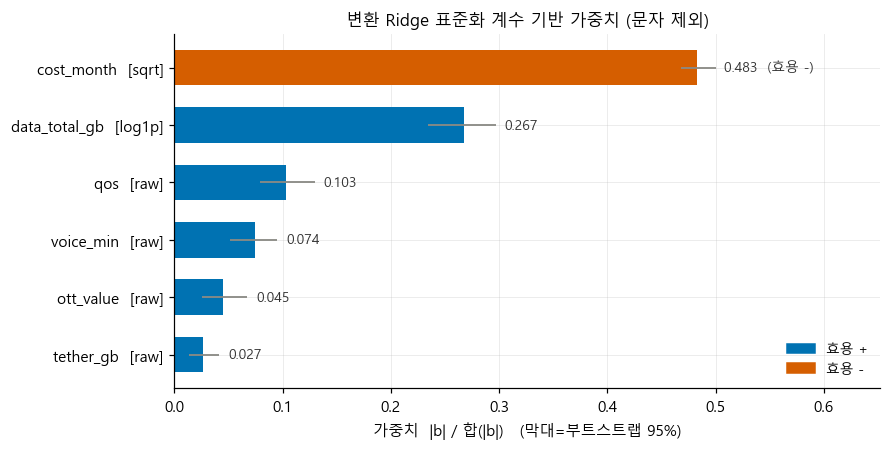

In [14]:
order = WEIGHTS.index[::-1]
vals = WEIGHTS[order].values
# 점추정이 부트스트랩 구간 밖으로 조금 벗어날 수 있어 0 에서 자른다 (errorbar 가 음수를 못 받는다)
lo = (WEIGHTS[order] - boot_w.quantile(0.025)[order]).clip(lower=0).values
hi = (boot_w.quantile(0.975)[order] - WEIGHTS[order]).clip(lower=0).values
neg = (coef[order] < 0).values

fig, ax = plt.subplots(figsize=(8.2, 4.2))
pos = np.arange(len(order))
ax.barh(pos, vals, xerr=[lo, hi], color=np.where(neg, VERM, BLUE), height=0.62,
        error_kw=dict(ecolor=MUTED, lw=1.2))
for p, v, n in zip(pos, vals, neg):
    ax.text(v + hi[p] + 0.008, p, f"{v:.3f}" + ("  (효용 -)" if n else ""),
            va="center", fontsize=9, color="#333")
ax.set_yticks(pos, [f"{n}  [{spec[n]}]" for n in order], fontsize=10)
ax.set_xlabel("가중치  |b| / 합(|b|)   (막대=부트스트랩 95%)")
ax.set_xlim(0, vals.max() * 1.35)
ax.set_title("변환 Ridge 표준화 계수 기반 가중치 (문자 제외)", fontsize=11)
handles = [plt.Rectangle((0, 0), 1, 1, color=BLUE), plt.Rectangle((0, 0), 1, 1, color=VERM)]
ax.legend(handles, ["효용 +", "효용 -"], frameon=False, fontsize=9, loc="lower right")
tidy(ax)
fig.tight_layout()
fig.savefig("fig_weights.png", bbox_inches="tight")
plt.show()

## 통화 가중치가 낮은 건 통화가 안 중요해서가 아니다

이 숫자를 처음 보면 걸린다. 실제로 요금제를 고를 때 통화를 보는데 가중치가 0.07이면
거의 영향이 없다는 말처럼 읽힌다.

가중치는 "사용자가 얼마나 중요하게 여기나"가 아니라 "요금제를 얼마나 갈라놓나"를 잰다.
후보군의 90.7%가 이미 통화 무제한이다. 100개 시나리오 중 34개는 후보 전원의 통화 조건이
똑같아서, 가중치를 1.0으로 줘도 순위가 안 바뀐다.

그리고 통화 조건 자체는 **필터가 먼저 거른다.** `scoring.py`에서 "통화 무제한"은 필터라
조건이 안 맞는 요금제는 후보에서 아예 빠진다. 점수는 그걸 통과한 것들 사이 순위만
매긴다. 필터로 이미 걸렀는데 점수에서 또 크게 반영하면 이중 계산이다.

실제 순위에 미치는 힘을 재보면 통화는 12.6%로 qos(13.2%)와 거의 같다. 가중치는 낮은데
후보군 안에서 `s_voice` 값이 크게 갈리기 때문이다. 리포트에 이 문장을 넣어야 한다.

## 안 된 것

변환 후에도 `gbm_d3`와 0.10쯤 차이가 남는다. 곱항(SHAP 상위 3·5·8개)도 넣어보고
질량점 더미(`is_data_unlim` 같은 것 6개)도 넣어봤는데 둘 다 0.49 언저리에서 멈췄다.
트리가 뭘 잡고 있는지는 결국 못 알아냈다.

축당 계수 하나를 유지하는 한 이 차이는 안 없어진다. 그게 계수를 가중치로 읽는 대가다.
없애려 들 게 아니라 리포트에 숫자로 적어두는 게 맞다.

`data_unlimited` 가 이 표본에 0개다. `scoring.py` 의 `DATA_MAX = 300` 은 무제한 대체값
겸 점수 분모인데, 실제 최댓값이 250이라 `s_data` 가 0.83 위로 못 올라간다. 다른 축은
실제 최댓값으로 나누는데 데이터만 도달 불가능한 분모를 쓰고 있다. 별건이라 안 고쳤다.


## SMAA-2에 넣을 가중치 표본

SMAA-2는 base 가중치 하나가 아니라 그 주변 n개로 순위를 다시 매겨서 추천이 버티는지
본다. n개를 어디서 뽑느냐가 여기서 정할 게 있는 유일한 부분이다.

균등 Dirichlet 같은 걸 씌울 수도 있는데 안 했다. 두 가지가 망가진다.

축마다 불확실성 크기가 다르다. cost는 95% 폭이 tether의 두 배쯤 된다. 균등하게 흔들면
tether를 실제보다 크게 흔들게 된다.

축끼리 상관도 있다. 합이 1이라 음의 상관이 자동으로 들어가고, cost와 data는 공선성
때문에 서로 뺏고 뺏긴다. 따로따로 흔들면 실제로는 안 나오는 조합이 나온다. 통화·문자에서
겪은 게 바로 그 문제다.

위 부트스트랩이 이미 그 불확실성 자체를 표본으로 갖고 있다. 그대로 쓰면 분포 가정이
하나도 안 들어간다.

축 이름만 `scoring.py` 쪽으로 바꿔서 내보낸다. 문자는 회귀 단계에서 이미 빠져 있으므로
여기서 따로 걸러낼 게 없다.


In [15]:
# n을 늘리려면 N_DRAWS 만 키우면 된다. 결과는 CSV 로 캐시된다.
N_DRAWS = 2000
PROD = {"cost_month": "cost", "data_total_gb": "data", "qos": "qos",
        "tether_gb": "tether", "voice_min": "voice", "ott_value": "ott"}
assert set(PROD) == set(FINAL)

rng = np.random.default_rng(7)
draws = []
for _ in range(N_DRAWS):
    i = rng.choice(len(Xf), len(Xf), replace=True)
    c = coef_of(Xf.iloc[i], FINAL, y[i]).abs()
    draws.append(c / c.sum())

DRAWS = pd.DataFrame(draws).rename(columns=PROD)
DRAWS.to_csv("../data/weight_draws.csv", index=False)

base = WEIGHTS.rename(PROD)
print(pd.DataFrame({"base": base, "표본 평균": DRAWS.mean(),
                    "2.5%": DRAWS.quantile(0.025), "97.5%": DRAWS.quantile(0.975)})
      .round(4).sort_values("base", ascending=False).to_string())
print(f"\n{len(DRAWS)}개 x {DRAWS.shape[1]}축 -> data/weight_draws.csv")

assert np.allclose(DRAWS.sum(axis=1), 1.0)
assert (DRAWS > 0).all().all(), "가중치가 0 이하인 표본이 있다"

print("\n현행 scoring.py WEIGHTS 와 비교:")
print(pd.DataFrame({
    "신규": base.round(3),
    "현행": pd.Series({"cost": 0.499, "data": 0.258, "ott": 0.083,
                     "qos": 0.067, "tether": 0.061, "voice": 0.032}),
}).to_string())

          base   표본 평균    2.5%   97.5%
cost    0.4829  0.4833  0.4681  0.4987
data    0.2673  0.2673  0.2378  0.2985
qos     0.1033  0.1035  0.0768  0.1297
voice   0.0744  0.0742  0.0523  0.0941
ott     0.0453  0.0448  0.0253  0.0652
tether  0.0268  0.0269  0.0113  0.0419

2000개 x 6축 -> data/weight_draws.csv

현행 scoring.py WEIGHTS 와 비교:
           신규     현행
cost    0.483  0.499
data    0.267  0.258
ott     0.045  0.083
qos     0.103  0.067
tether  0.027  0.061
voice   0.074  0.032


## 자기점검

절차가 진짜 작동하는지 합성자료로 확인한다. 상호작용을 넣은 자료에서 잡아내는지,
없는 자료에서 헛것을 보지 않는지.


In [16]:
def _check():
    rng = np.random.default_rng(0)
    n, cv = 800, RepeatedKFold(n_splits=3, n_repeats=2, random_state=0)
    Z = pd.DataFrame(rng.normal(size=(n, 4)), columns=list("abcd"))

    # 1) 순수 가법. 갭이 유의하게 양수면 안 된다 (음수는 정상: depth3 이 헛되이 복잡)
    y_add = 2 * Z.a - 1.5 * Z.b + 0.8 * Z.c + rng.normal(scale=0.5, size=n)
    g = gap(run_cv(Z, y_add.values, cv), "gbm_d3", "gbm_d1")
    assert g[0] - g[1] <= 0, f"가법인데 상호작용 탐지됨: {g}"

    # 2) 강한 곱항. 갭이 유의하게 양수여야 한다
    y_int = 2 * Z.a - 1.5 * Z.b + 3.0 * Z.a * Z.b + rng.normal(scale=0.5, size=n)
    g = gap(run_cv(Z, y_int.values, cv), "gbm_d3", "gbm_d1")
    assert g[0] > g[1], f"곱항 있는데 못 잡음: {g}"

    # 3) 공선성 진단. 문자 계수가 뒤집힌 걸 "짝을 빼면 계수가 크게 달라진다"로 판정했다.
    #    그 판정이 상관이 높을 때만 반응하고 낮을 때는 잠잠한지 확인한다.
    def shift(corr_target):
        x1 = rng.normal(size=n)
        noise = np.sqrt(1 / corr_target ** 2 - 1)
        Z2 = pd.DataFrame({"x1": x1, "x2": x1 + rng.normal(scale=noise, size=n)})
        yy = (1.0 * Z2.x1 - 0.3 * Z2.x2 + rng.normal(scale=0.5, size=n)).values
        both = make_pipeline(StandardScaler(), RidgeCV(alphas=ALPHAS)).fit(Z2, yy)[-1].coef_[1]
        solo = make_pipeline(StandardScaler(), RidgeCV(alphas=ALPHAS)).fit(
            Z2[["x2"]], yy)[-1].coef_[0]
        return abs(both - solo)

    hi, lo = shift(0.96), shift(0.20)
    assert hi > 3 * lo, f"공선성 판정이 반응하지 않는다: 높음 {hi:.3f} 낮음 {lo:.3f}"
    print(f"  공선성 판정: 상관 0.96 일 때 계수 이동 {hi:.3f} · 상관 0.20 일 때 {lo:.3f}")

    print("자기점검 통과")


_check()

  공선성 판정: 상관 0.96 일 때 계수 이동 1.006 · 상관 0.20 일 때 0.246
자기점검 통과
